# **Diabetes Risk Prediction Model**

This notebook trains and evaluates several machine learning models to predict diabetes based on a patient's health data.




## Setup: Install packages and import dependencies

In [1]:
# Install needed packages
!pip install --quiet scikit-learn pandas numpy matplotlib seaborn xgboost lightgbm catboost imbalanced-learn joblib

# Standard imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## Load Dataset

Load the diabetes dataset and perform initial validation by inspecting the dataset dimensions, previewing sample records, and checking the class distribution.

In [2]:
# Load dataset
url = "https://raw.githubusercontent.com/AnDh08/Diabetes-Risk-Predictor/main/ml/data/diabetes_health_indicators.csv"
df = pd.read_csv(url)

print("Rows, cols:", df.shape)
print(df.head())

# Check whether the target classes are imbalanced
print("\nClass counts:")
print(df['Diabetes_binary'].value_counts().sort_index())
print("Neg/Pos ratio:", df['Diabetes_binary'].value_counts().iloc[0] / df['Diabetes_binary'].value_counts().iloc[1])

Rows, cols: (70692, 22)
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       0.0        1.0  26.0     0.0     0.0   
1              0.0     1.0       1.0        1.0  26.0     1.0     1.0   
2              0.0     0.0       0.0        1.0  26.0     0.0     0.0   
3              0.0     1.0       1.0        1.0  28.0     1.0     0.0   
4              0.0     0.0       0.0        1.0  29.0     1.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           1.0     0.0  ...            1.0   
1                   0.0           0.0     1.0  ...            1.0   
2                   0.0           1.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      3.0       5.0      30.0

## Feature Engineering

Create additional features that may improve model performance. These engineered features capture age-related risk and combined lifestyle factors associated with diabetes.




In [3]:
data = df.copy()

# Engineered features
data['IsSenior'] = (data['Age'] >= 9).astype(float) # Encoded into categories where age >=9 represends older adults
data['PoorAct&PoorDiet'] = (
    (data['PhysActivity'] == 0) & ((data['Fruits'] == 0) | (data['Veggies'] == 0))
).astype(float)

# List of features used for model
feature_cols = [
    "HighBP","HighChol","CholCheck","BMI","Smoker","Stroke","HeartDiseaseorAttack",
    "PhysActivity","Fruits","Veggies","HvyAlcoholConsump","AnyHealthcare","NoDocbcCost",
    "GenHlth","MentHlth","PhysHlth","DiffWalk","Sex","Age","Education","Income",
    "IsSenior","PoorAct&PoorDiet"
]

X = data[feature_cols]
y = data['Diabetes_binary'].astype(int)

print("X shape:", X.shape)

X shape: (70692, 23)


## Train-Test Split

Split the dataset into training and testing sets. Separate splits are created for the engineered feature matrix and the raw dataset so the final preprocessing pipeline can be evaluated end-to-end.

In [4]:
from sklearn.model_selection import train_test_split

# Split the engineered feature matrix into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# Split the original DataFrame using the same parameters for evaluation on raw input data
X_raw_train, X_raw_test, _, _ = train_test_split(
    df, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# Display the sizes of the resulting training and testing datasets.
print("Engineered: Train:", X_train.shape, "Test:", X_test.shape)
print("Raw rows:    Train:", X_raw_train.shape, "Test:", X_raw_test.shape)

Engineered: Train: (56553, 23) Test: (14139, 23)
Raw rows:    Train: (56553, 22) Test: (14139, 22)


## Data Preprocessing

Create a preprocessing pipeline that imputes missing values and standardizes numerical features. A `KNNImputer` is used by default for better data quality, while a `SimpleImputer` is provided as a faster alternative for experimentation.


In [5]:
# Import preprocessing tools
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# All features are treated as numerical
numeric_cols = X_train.columns.tolist()

# Default: KNNImputer (higher quality, slower)
numeric_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=6)),
    ('scaler', StandardScaler())
])

# Alternative: SimpleImputer (faster, lower quality)
# numeric_transformer = Pipeline([
#    ('imputer', SimpleImputer(strategy='median')),
#    ('scaler', StandardScaler())
# ])

# Apply the preprocessing pipeline to all numerical features
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols)
], remainder='drop')

## Classifiers

Define a set of machine learning algorithms to compare. These models include linear, tree-based, ensemble, and gradient boosting methods, allowing performance to be evaluated across different learning approaches.

In [6]:
# Import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Define a collection of model to compare
models = {
    "LogisticRegression": LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=1, eval_metric='auc', verbosity=0),
    "LightGBM": LGBMClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=200, learning_rate=0.05, depth=5, random_seed=RANDOM_STATE, verbose=0)
}

## Model Comparison Using Cross-Validation

Evaluate multiple classifiers using stratified k-fold cross-validation. ROC-AUC is used as the primary metric because it measures ranking performance and is more reliable than accuracy when dealing with imbalanced classification problems.


In [7]:
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Maintain the same proportion of diabetic and non-diabetic samples in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = "roc_auc"
results = []

# Train and evaluate each model using same pipeline
for name, est in models.items():
    print(f"Running CV for {name} ...", end=' ')

    # Prevent data leakage by combining preprocessing and model
    pipe = SkPipeline([("preproc", preprocessor), ("clf", est)])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)

    # Store mean and variation for comparison
    results.append({
        "Model": name,
        "ROC_AUC_mean": float(np.mean(scores)),
        "ROC_AUC_std": float(np.std(scores))
    })

    print(f"done. mean ROC_AUC = {np.mean(scores):.4f}, std = {np.std(scores):.4f}")

# Rank models by performance
results_df = pd.DataFrame(results).sort_values("ROC_AUC_mean", ascending=False).reset_index(drop=True)
print("\nSummary (sorted by mean ROC-AUC):")
display(results_df)

Running CV for LogisticRegression ... done. mean ROC_AUC = 0.8249, std = 0.0021
Running CV for DecisionTree ... done. mean ROC_AUC = 0.6540, std = 0.0034
Running CV for RandomForest ... done. mean ROC_AUC = 0.8093, std = 0.0021
Running CV for ExtraTrees ... done. mean ROC_AUC = 0.7895, std = 0.0031
Running CV for GradientBoosting ... done. mean ROC_AUC = 0.8305, std = 0.0016
Running CV for MLP ... done. mean ROC_AUC = 0.7981, std = 0.0047
Running CV for XGBoost ... done. mean ROC_AUC = 0.8302, std = 0.0019
Running CV for LightGBM ... 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


done. mean ROC_AUC = 0.8301, std = 0.0020
Running CV for CatBoost ... done. mean ROC_AUC = 0.8312, std = 0.0018

Summary (sorted by mean ROC-AUC):


,Model,ROC_AUC_mean,ROC_AUC_std
0,CatBoost,0.831200,0.001842
1,GradientBoosting,0.830451,0.001571
2,XGBoost,0.830243,0.001916
3,LightGBM,0.830120,0.001984
4,LogisticRegression,0.824913,0.002120
5,RandomForest,0.809339,0.002145
6,MLP,0.798126,0.004658
7,ExtraTrees,0.789546,0.003054
8,DecisionTree,0.653976,0.003361


## Cross-Validation Performance Visualization

Visualize the average ROC-AUC score for each model to make performance differences easier to compare.

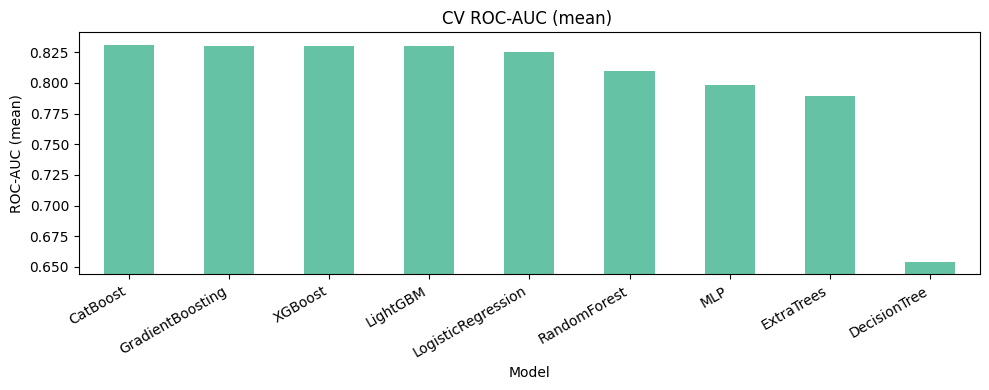

In [8]:
# Visualize cross-validation performance across models
ax = results_df.set_index("Model")["ROC_AUC_mean"].plot(
    kind="bar", figsize=(10,4), ylim=(results_df["ROC_AUC_mean"].min() - 0.01, results_df["ROC_AUC_mean"].max() + 0.01),
    colormap="Set2"
)

ax.set_ylabel("ROC-AUC (mean)")
ax.set_title("CV ROC-AUC (mean) ")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Final Pipeline Evaluation

The selected model is evaluated using an end-to-end pipeline that accepts raw patient data, applies feature engineering and preprocessing, and generates predictions.


Best model by CV ROC-AUC: CatBoost
Pipeline(steps=[('feat',
                 FunctionTransformer(func=<function make_features at 0x7efca86151c0>)),
                ('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=6)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['HighBP', 'HighChol',
                                                   'CholCheck', 'BMI', 'Smoker',
                                                   'Stroke',
                                                   'HeartDiseaseorAttack',
                                                   'PhysActivity', 'Fruits',
                                                   'Veggies',


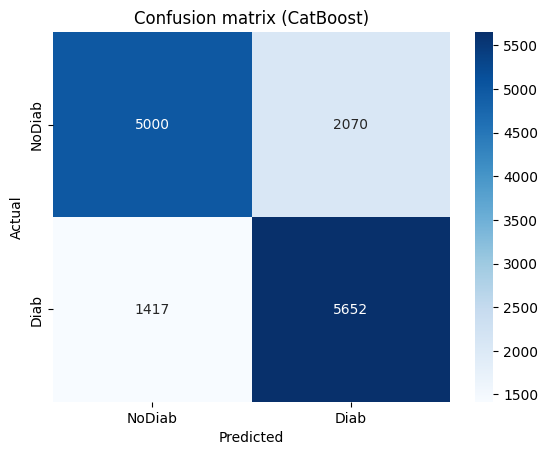

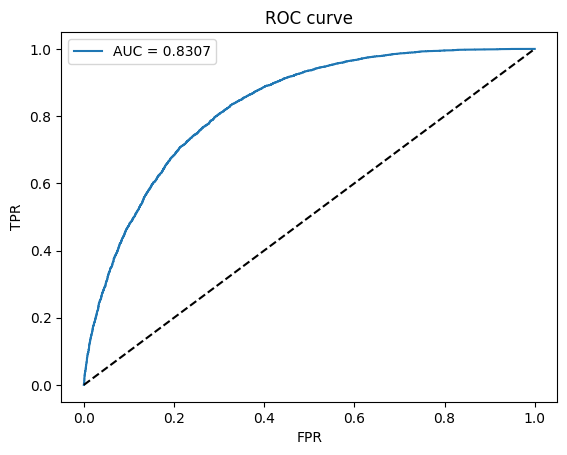

In [9]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from ml.preprocessing import make_features

feat_transformer = FunctionTransformer(make_features, validate=False)

# Select the best performing model
best_name = results_df.loc[0, "Model"]
print("Best model by CV ROC-AUC:", best_name)
best_estimator = models[best_name]

# Final pipeline:
# Raw data -> Feature engineering -> Preprocessing -> Model prediction
final_pipeline = SkPipeline([("feat", feat_transformer), ("preproc", preprocessor), ("clf", best_estimator)])
print(final_pipeline)

# Fit on raw train rows and evaluate on raw test rows
print("\nFitting final pipeline on raw train rows and evaluating on raw test rows...")
final_pipeline.fit(X_raw_train, y_train)

y_pred = final_pipeline.predict(X_raw_test)
y_proba = final_pipeline.predict_proba(X_raw_test)[:, 1]

# Evaulute multiple classifcation metrics for model
print("\nHoldout Test metrics:")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NoDiab','Diab'], yticklabels=['NoDiab','Diab'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'Confusion matrix ({best_name})'); plt.show()

# ROC curve plot
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr,tpr):.4f}")
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC curve'); plt.legend(); plt.show()

## Final Model Training and Artifact Export

Retrain the selected pipeline using the complete dataset and save the trained artifact for future deployment. The saved pipeline contains all feature engineering and preprocessing steps required for inference on new patient data.


In [10]:
import joblib

# Retrain the selected pipeline using the complete dataset
print("Fitting final pipeline on full raw dataset (for deployment)...")
final_pipeline.fit(df, y)   # df = raw original dataframe

# Create directory for saved model artifacts
os.makedirs("../ml/artifacts", exist_ok=True)
artifact_path = "../ml/artifacts/final_pipeline.joblib"
joblib.dump(final_pipeline, artifact_path)
joblib.dump(feature_cols, "../ml/artifacts/feature_cols.joblib")

print("Saved pipeline to", artifact_path)

Fitting final pipeline on full raw dataset (for deployment)...
Saved pipeline to ../ml/artifacts/final_pipeline.joblib


## Artifact Loading and Inference Test

Reload the saved model pipeline and perform a test prediction using a raw dataset row. This verifies that the exported artifact can be used for inference outside of the training environment.


In [11]:
import joblib

# Load the complete pipeline
pipe = joblib.load("../ml/artifacts/final_pipeline.joblib")
print("Loaded:", pipe)

# Test prediction using a single raw data row
raw_row = df.iloc[[0]].copy()
print("Raw sample:\n", raw_row.to_dict(orient='records')[0])

# Generate predicted class and probability score
prediction = pipe.predict(raw_row)
probability = pipe.predict_proba(raw_row)[:, 1]

print("Prediction:", prediction)
print("Probability:", probability)

Loaded: Pipeline(steps=[('feat',
                 FunctionTransformer(func=<function make_features at 0x7efca86151c0>)),
                ('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=6)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['HighBP', 'HighChol',
                                                   'CholCheck', 'BMI', 'Smoker',
                                                   'Stroke',
                                                   'HeartDiseaseorAttack',
                                                   'PhysActivity', 'Fruits',
                                                   'Veggies',
                           